In [2]:
# Install Dependencies
!pip install -U kagglehub
!pip install midaa anndata scanpy matplotlib numpy seaborn scipy umap-learn torchvision torch wandb weave


In [ ]:
#Imports + WandB/Weave Initialization
import os, struct, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import kagglehub
import anndata as ad
import scanpy as sc
import umap
import midaa as maa

# WANDB + WEAVE
import wandb, weave

os.environ["WANDB_API_KEY"] = "INSERT YOUR WANDB"
wandb.login()

wandb.init(project="midaa-mnist", name="MNIST_MIDAA_Notebook")

# your weave version requires project_name
weave.init(project_name="midaa-mnist")

print("WandB + Weave initialized.")


wandb: WARNING Failed to create global config settings in: /Users/emmsi/.config/wandb. Settings will not be persisted.
wandb: Currently logged in as: s226625 (s226625-danmarks-tekniske-universitet-dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-mnist/weave


WandB + Weave initialized.


In [4]:
#Load MNIST Via KaggleHub
path = kagglehub.dataset_download("hojjatk/mnist-dataset") + "/"
print("MNIST path:", path)

def load_idx_images(folder):
    file = os.path.join(folder, os.listdir(folder)[0])
    with open(file, "rb") as f:
        _, n, r, c = struct.unpack(">IIII", f.read(16))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, r, c)

def load_idx_labels(folder):
    file = os.path.join(folder, os.listdir(folder)[0])
    with open(file, "rb") as f:
        _, n = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)

X = load_idx_images(path + "train-images-idx3-ubyte")
y = load_idx_labels(path + "train-labels-idx1-ubyte")

print("Loaded:", X.shape, y.shape)


MNIST path: /Users/emmsi/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1/
Loaded: (60000, 28, 28) (60000,)


In [5]:
# Subset + Build AnnData
subset = 5000
X = X[:subset]
y = y[:subset]

X_flat = X.reshape(subset, -1).astype(np.float32) / 255.0

adata = ad.AnnData(X_flat)
adata.obs["label"] = y.astype(str)        # replaces louvain
adata.obsm["images"] = X                  # store original images

print(adata)


AnnData object with n_obs × n_vars = 5000 × 784
    obs: 'label'
    obsm: 'images'


In [6]:
# Prepare MIDAA Inputs
input_data = [adata.X]
normalization = [np.ones(adata.n_obs)]
likelihoods = ["G"]
narchetypes = 5   # same as PBMC demo


In [7]:
# Fit MIDAA
res = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.001,
    steps=600,
    narchetypes=narchetypes
)

print("Unsupervised MIDAA complete.")

# Logging compatible with MNIST (ELBO not in inferred_quantities)
if "ELBO" in res:
    wandb.log({"final_elbo": res["ELBO"][-1]})
elif "loss_history" in res["inferred_quantities"]:
    wandb.log({"final_loss": res["inferred_quantities"]["loss_history"][-1]})


ELBO: 21618012.00000  : 100%|█████████████████| 600/600 [01:42<00:00,  5.83it/s]


Unsupervised MIDAA complete.


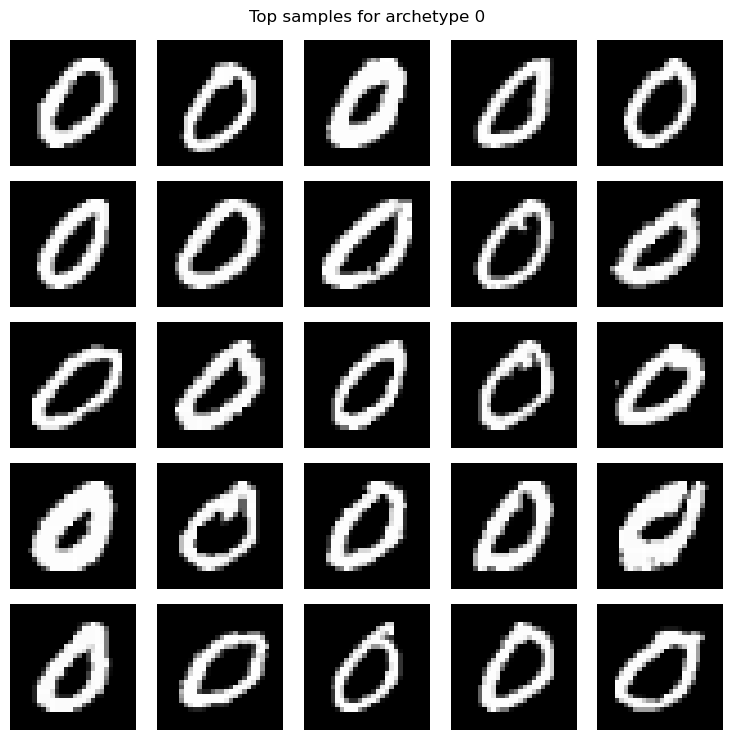

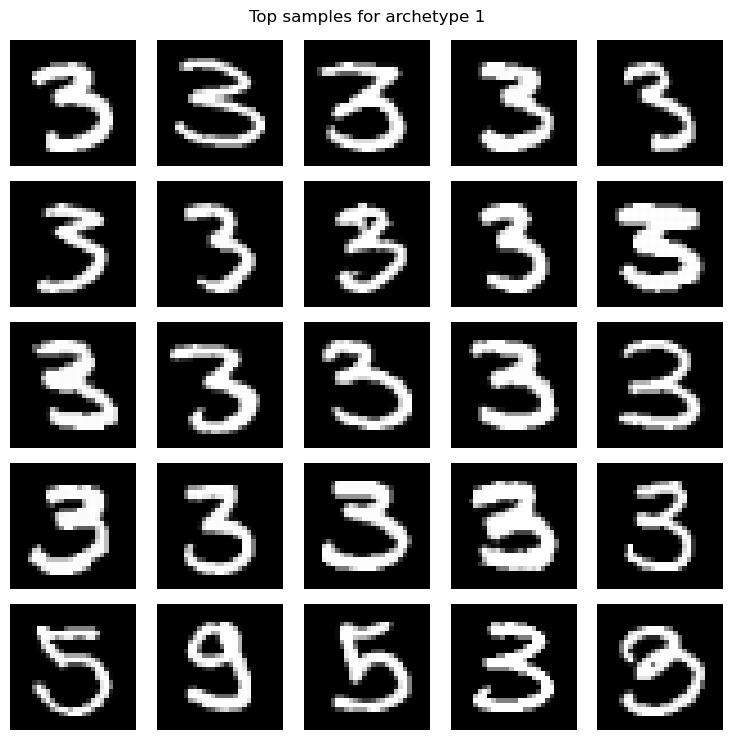

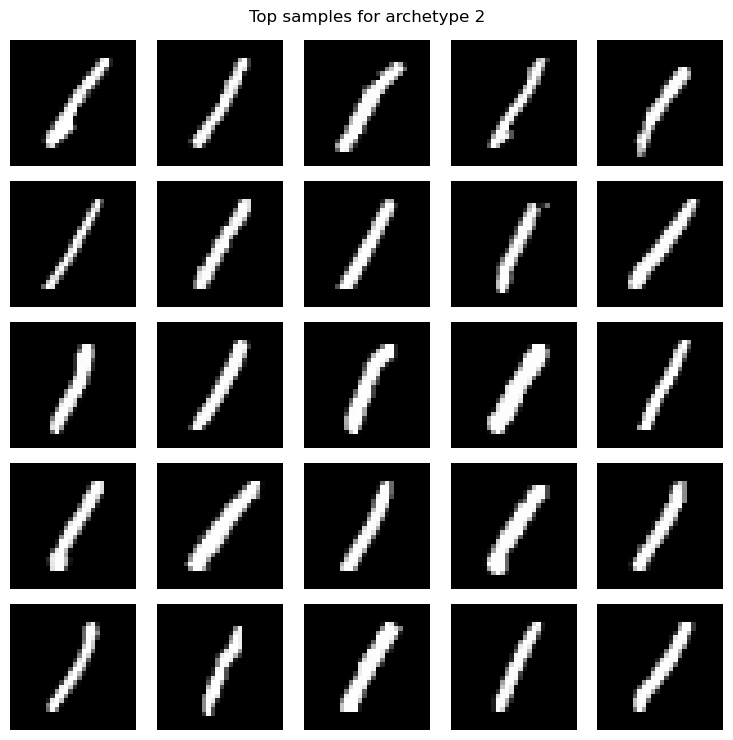

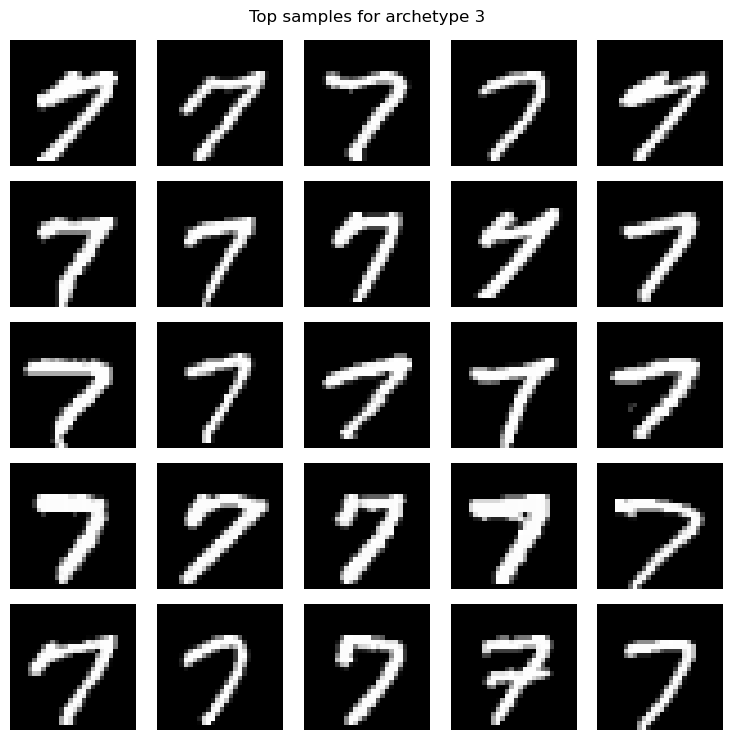

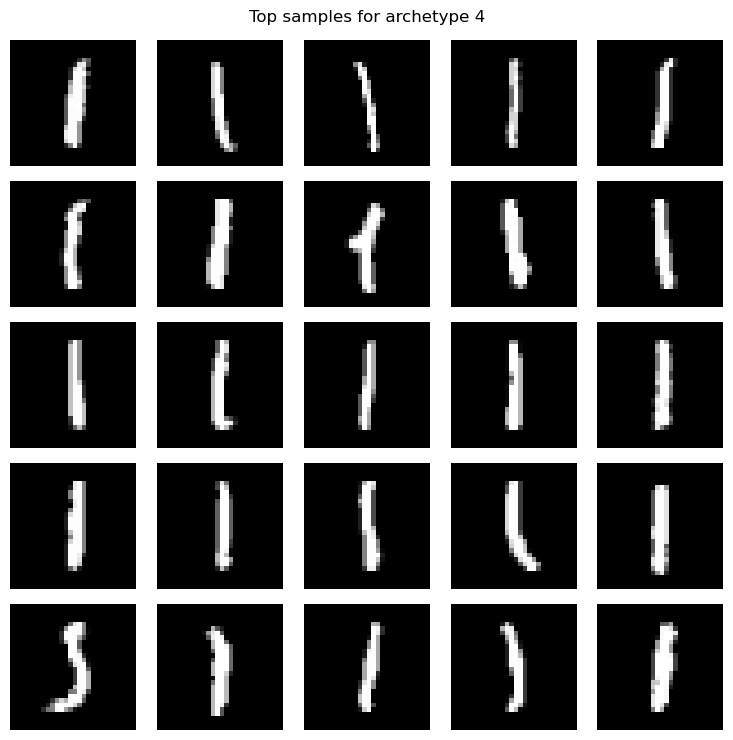

In [25]:
def show_top_samples(res, adata, top=25):
    A = res["inferred_quantities"]["A"]        # N × K responsibilities
    imgs = adata.obsm["images"]
    K = A.shape[1]

    for k in range(K):
        idx = np.argsort(-A[:, k])[:top]
        top_imgs = imgs[idx]

        m = int(np.ceil(np.sqrt(top)))
        plt.figure(figsize=(1.5*m, 1.5*m))
        for i in range(top):
            plt.subplot(m, m, i+1)
            plt.imshow(top_imgs[i], cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Top samples for archetype {k}")
        plt.tight_layout()
        plt.show()

show_top_samples(res, adata, top=25)



In [ ]:
# === 2. TOP SAMPLES FOR EACH ARCHETYPE ===

def show_top_samples(res, adata, top=25):
    A = res["inferred_quantities"]["A"]        # N × K responsibilities
    imgs = adata.obsm["images"]                # original MNIST images
    K = A.shape[1]

    for k in range(K):
        idx = np.argsort(-A[:, k])[:top]       # highest activations
        top_imgs = imgs[idx]

        m = int(np.ceil(np.sqrt(top)))
        plt.figure(figsize=(1.5*m, 1.5*m))
        for i in range(top):
            plt.subplot(m, m, i+1)
            plt.imshow(top_imgs[i], cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Top samples for archetype {k}")
        plt.tight_layout()
        plt.show()

show_top_samples(res, adata, top=25)


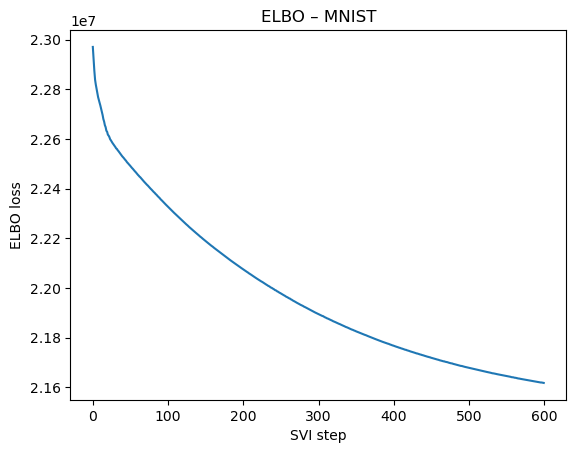

<Figure size 640x480 with 0 Axes>

In [8]:
# Plot ELBO
maa.plot_ELBO(res)
plt.title("ELBO – MNIST")
plt.show()

wandb.log({"elbo_curve": wandb.Image(plt.gcf())})



In [9]:
#Add Archetypes to AnnData

adata_unsup, arc_names = maa.add_to_obs_adata(res, adata.copy())
print("Archetype names:", arc_names)


Archetype names: ['arc1', 'arc2', 'arc3', 'arc4', 'arc5']


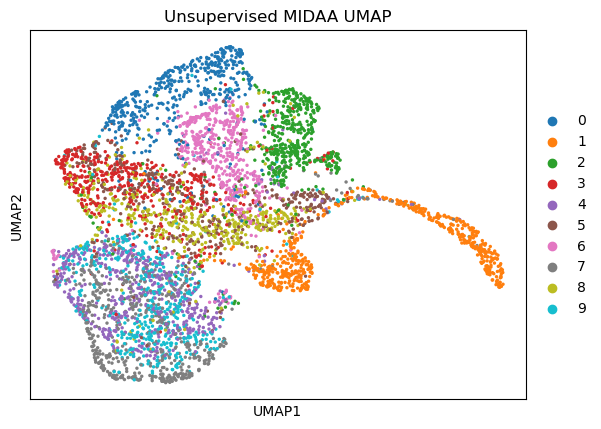

In [10]:
#UMAP

adata_unsup.obsm["X_aa"] = (
    res["inferred_quantities"]["A"]
    @ res["inferred_quantities"]["archetypes_inferred"]
)

sc.pp.neighbors(adata_unsup, use_rep="X_aa")
sc.tl.umap(adata_unsup)
sc.pl.umap(adata_unsup, color="label", title="Unsupervised MIDAA UMAP")


ELBO: 17617906.00000  : 100%|█████████████████| 600/600 [01:41<00:00,  5.89it/s]


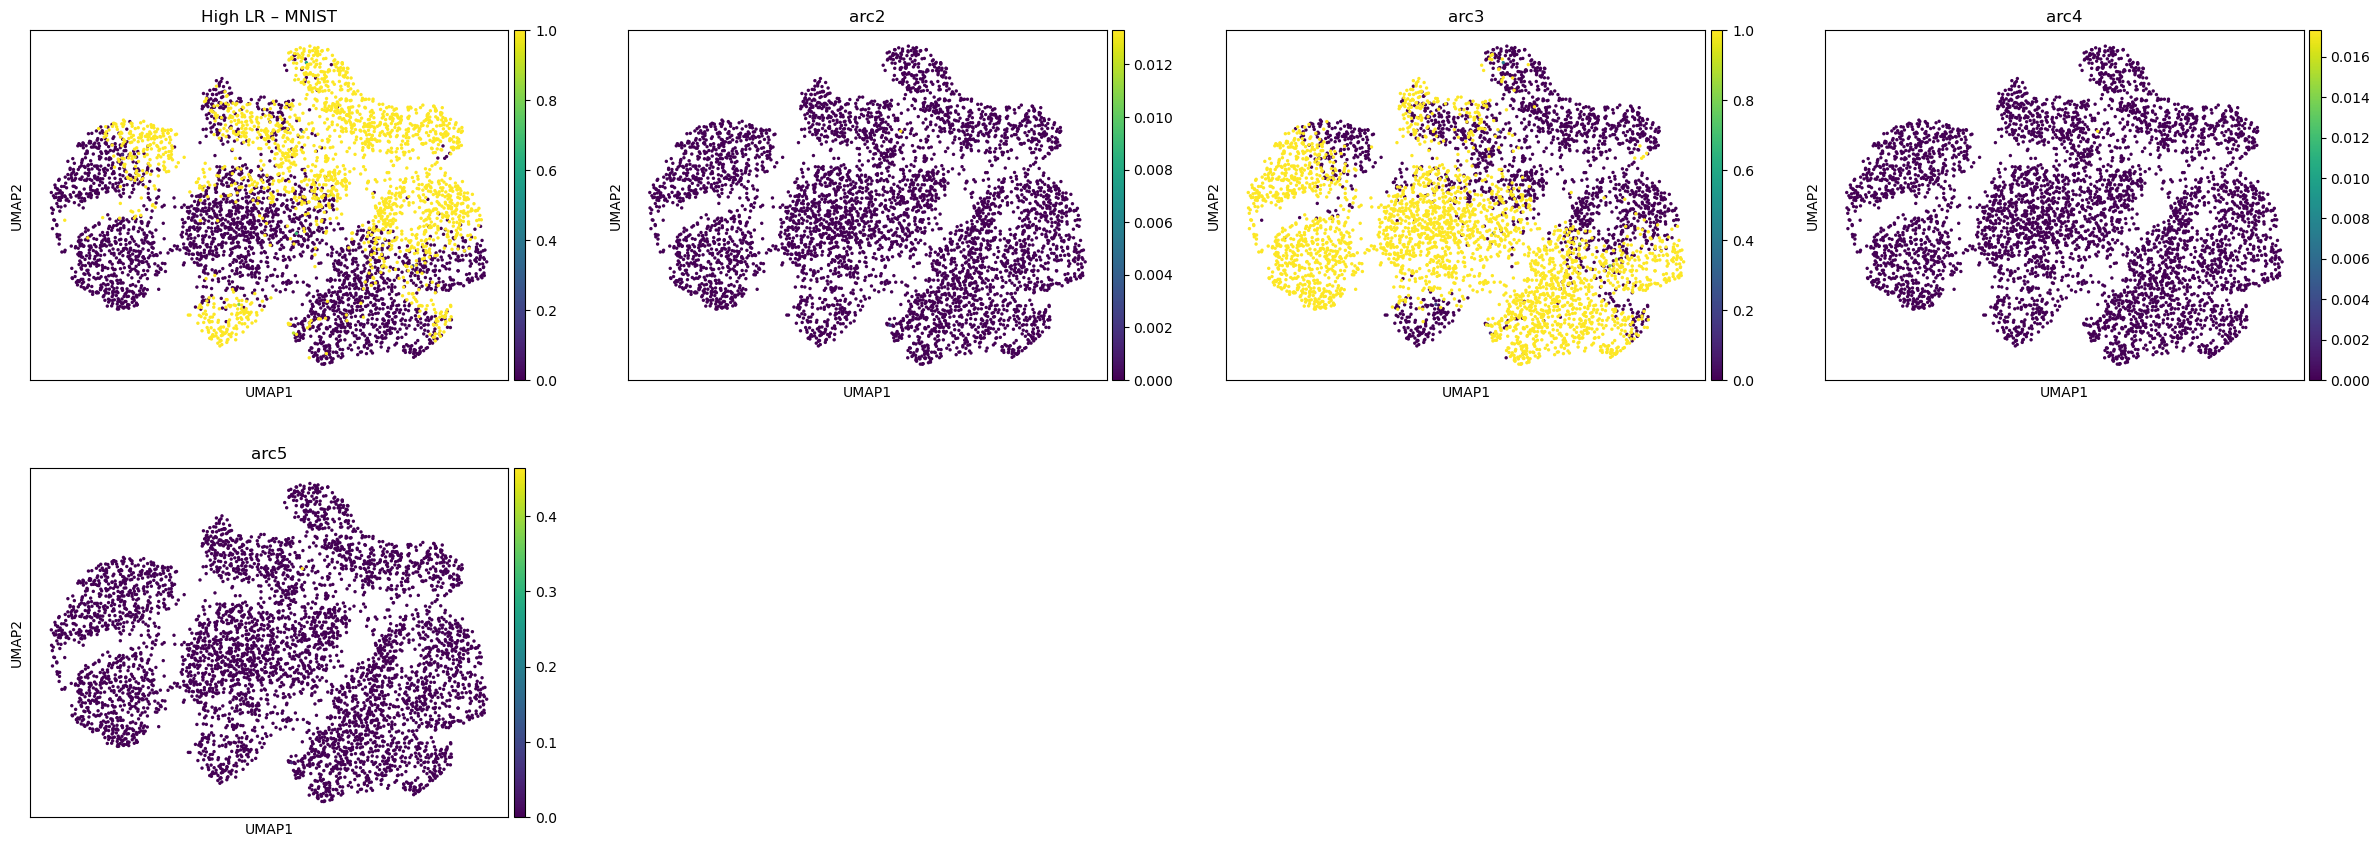

In [11]:
# HIGH LR
res_high = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.05,
    steps=600,
    narchetypes=narchetypes
)

adata_high, arc_high = maa.add_to_obs_adata(res_high, adata.copy())
sc.pp.neighbors(adata_high, use_rep="X")
sc.tl.umap(adata_high)
sc.pl.umap(adata_high, color=arc_high, title="High LR – MNIST")


ELBO: 22957138.00000  : 100%|█████████████████| 600/600 [01:44<00:00,  5.74it/s]


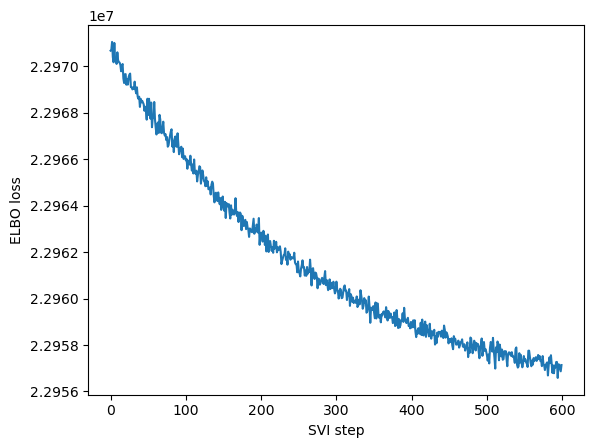

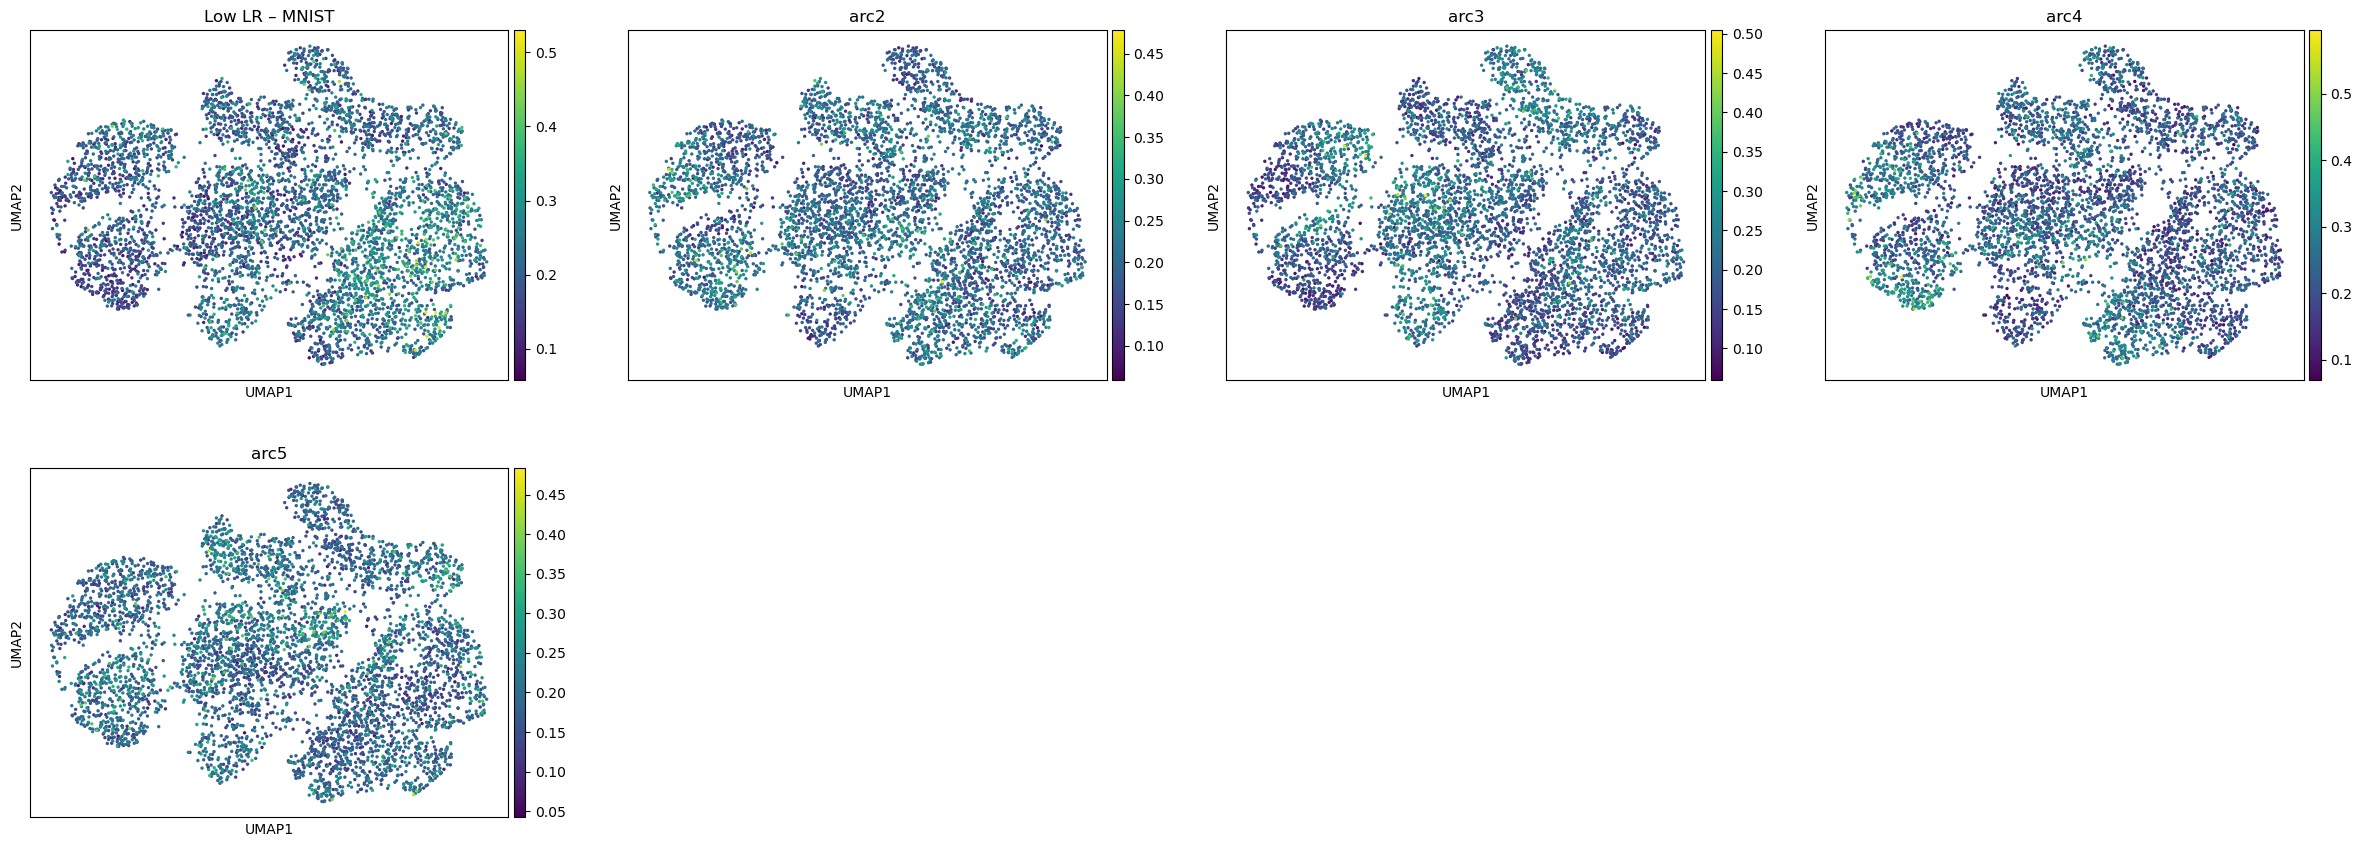

In [12]:
# LOW LR
res_low = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=1e-6,
    steps=600,
    narchetypes=narchetypes
)

maa.plot_ELBO(res_low)
plt.show()

adata_low, arc_low = maa.add_to_obs_adata(res_low, adata.copy())
sc.pp.neighbors(adata_low, use_rep="X")
sc.tl.umap(adata_low)
sc.pl.umap(adata_low, color=arc_low, title="Low LR – MNIST")


ELBO: 22819170.00000  : 100%|███████████████████| 10/10 [00:01<00:00,  5.28it/s]


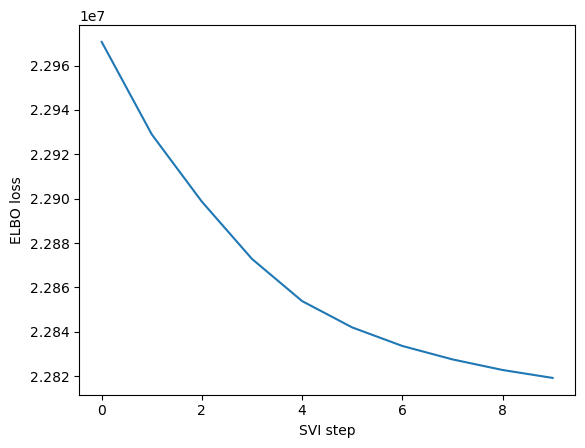

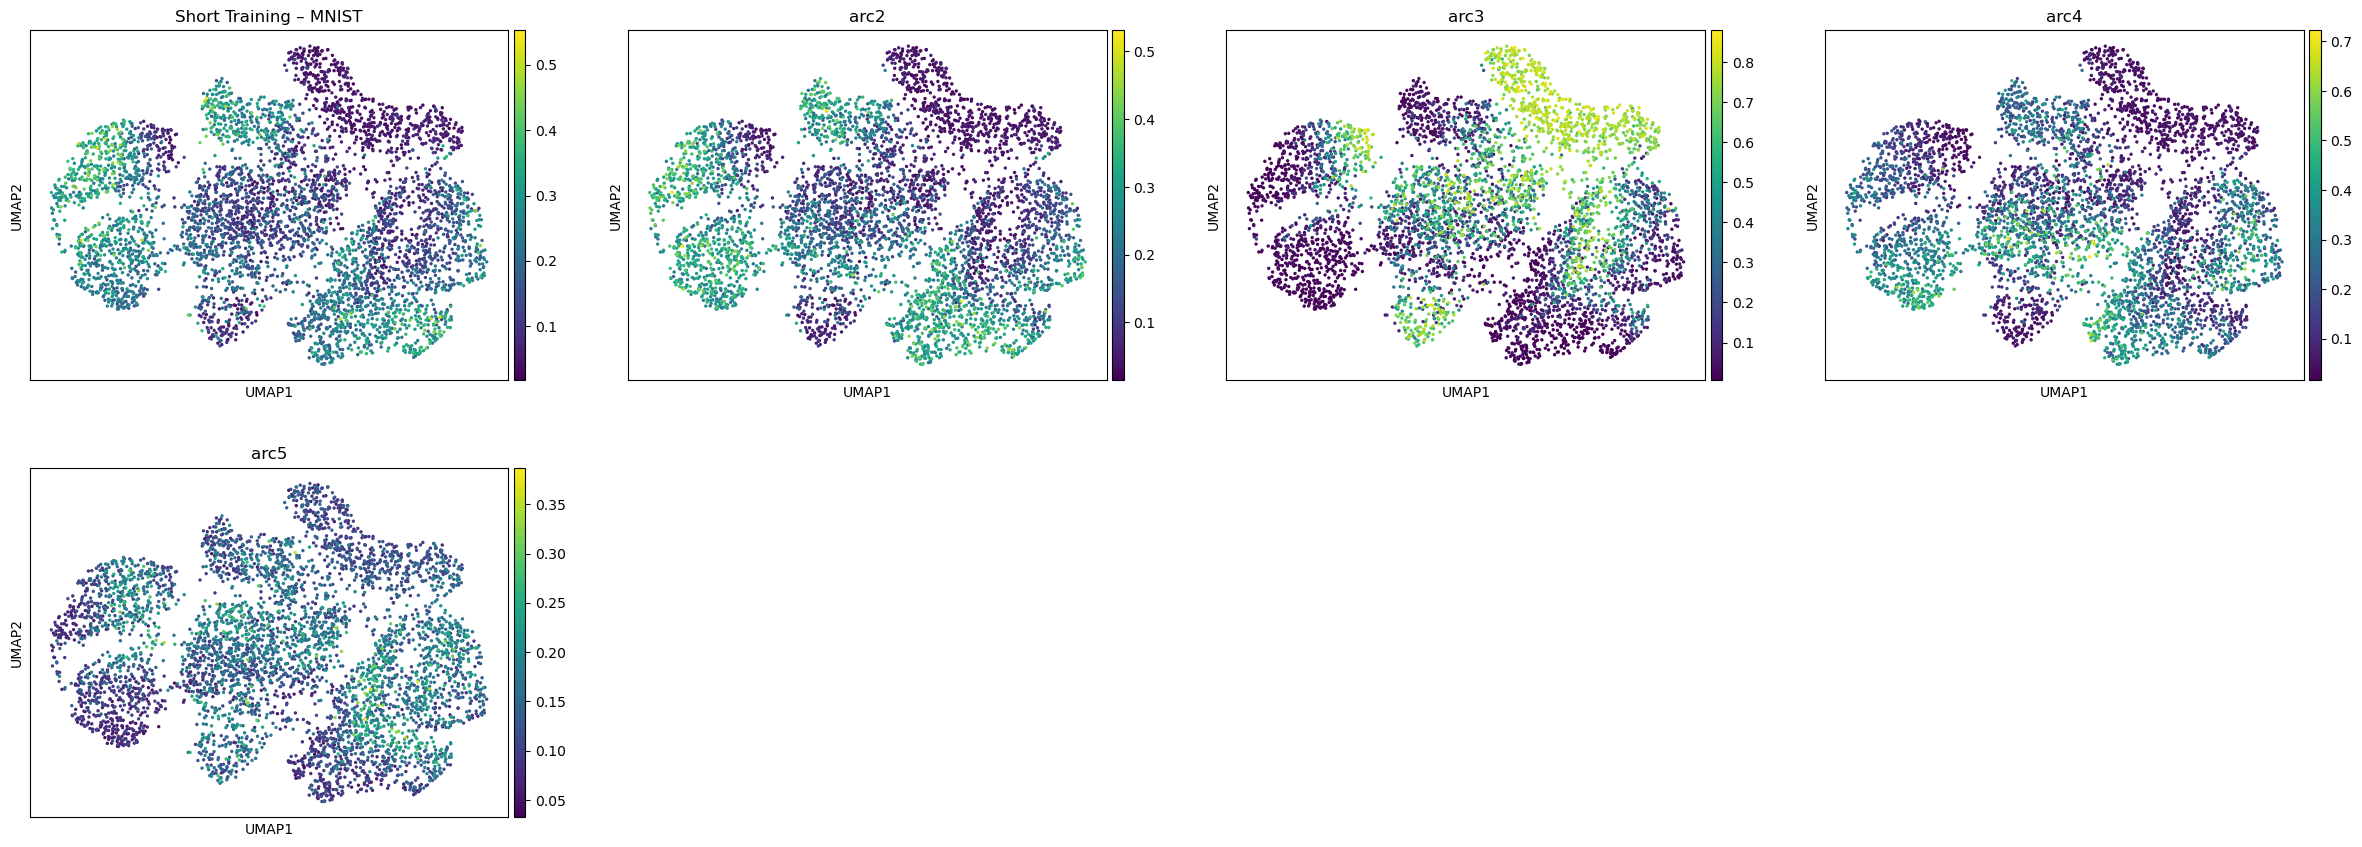

In [13]:
# Short Training

res_short = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.001,
    steps=10,
    narchetypes=narchetypes
)

maa.plot_ELBO(res_short)
plt.show()

adata_short, arc_short = maa.add_to_obs_adata(res_short, adata.copy())
sc.pp.neighbors(adata_short, use_rep="X")
sc.tl.umap(adata_short)
sc.pl.umap(adata_short, color=arc_short, title="Short Training – MNIST")


ELBO: 22267644.00000  : 100%|█████████████████| 500/500 [00:44<00:00, 11.11it/s]


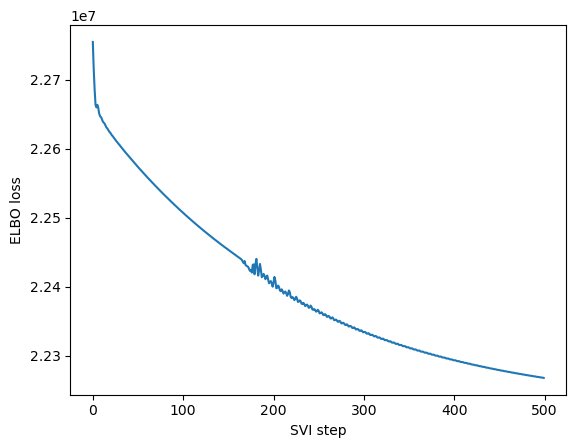

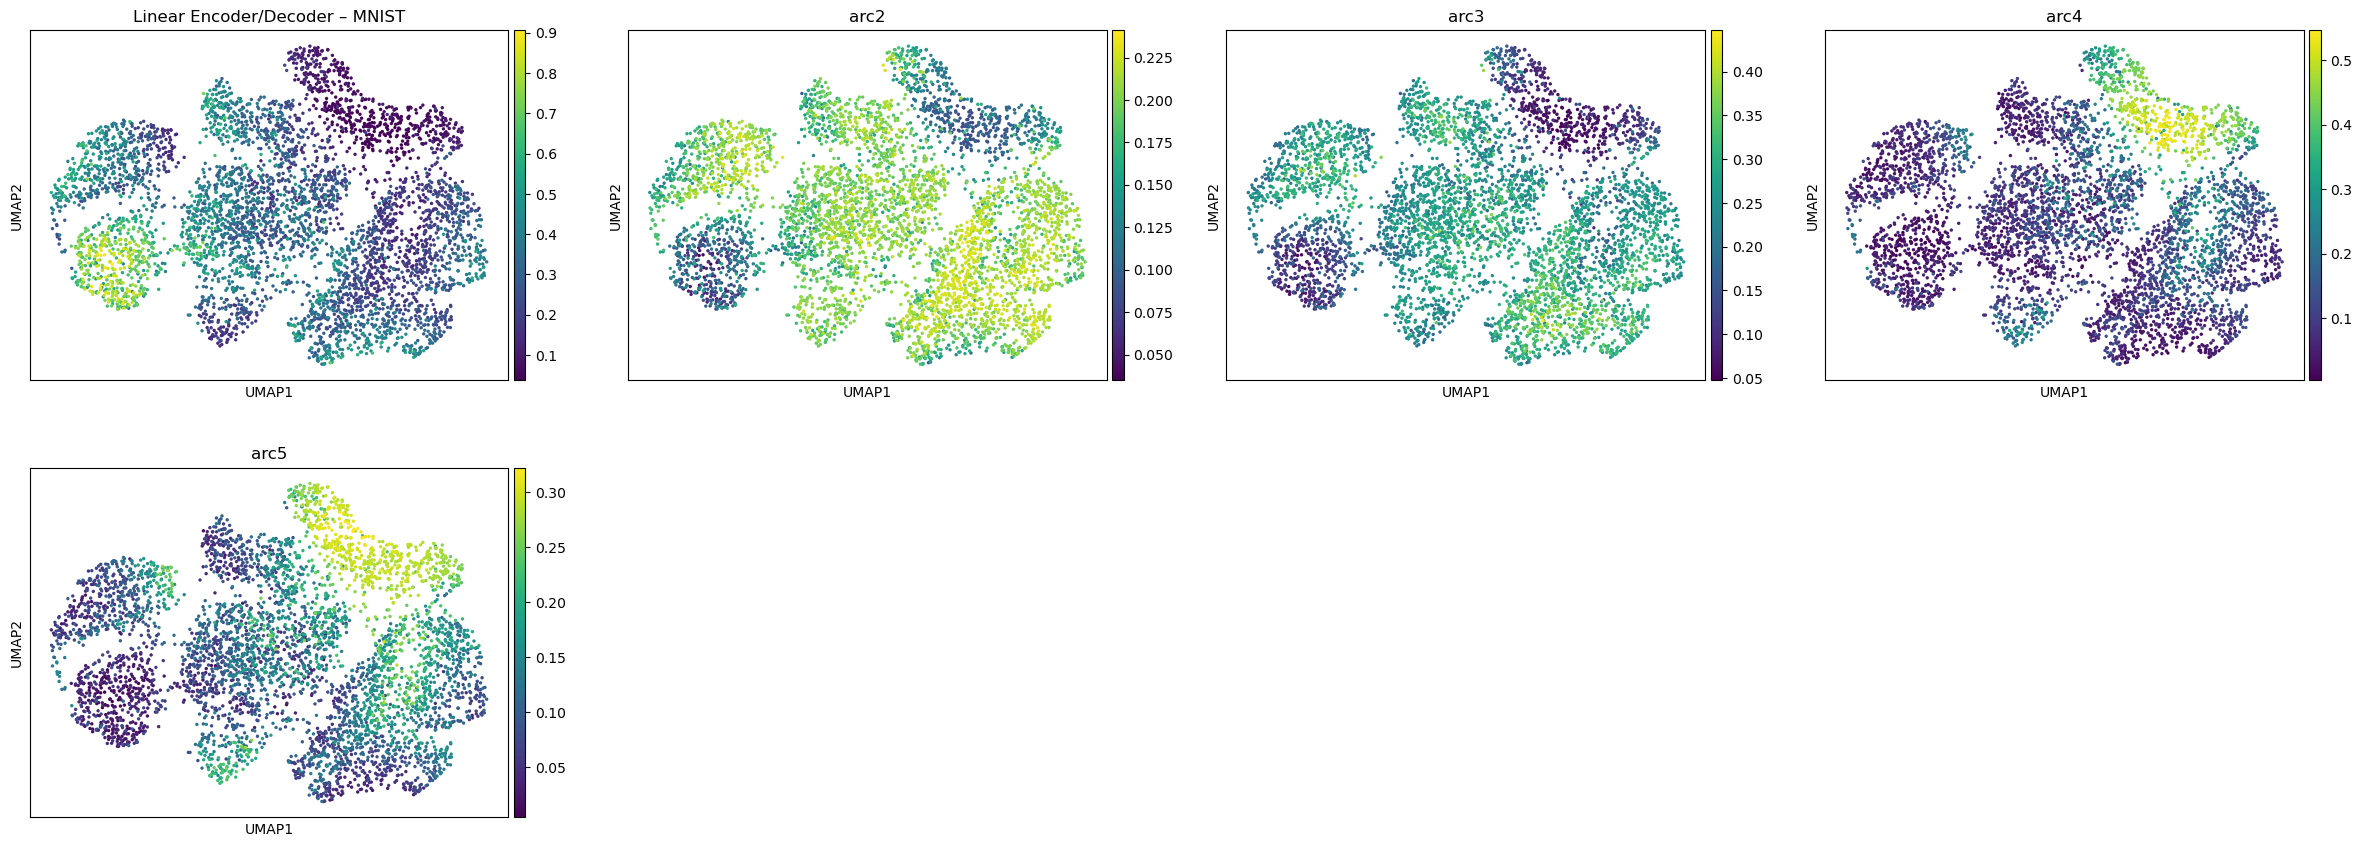

In [14]:
# Linear Encoder/Decoder
res_lin = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.0005,
    steps=500,
    narchetypes=narchetypes,
    linearize_encoder=True,
    linearize_decoder=True
)

maa.plot_ELBO(res_lin)
plt.show()

adata_lin, arc_lin = maa.add_to_obs_adata(res_lin, adata.copy())
sc.pp.neighbors(adata_lin, use_rep="X")
sc.tl.umap(adata_lin)
sc.pl.umap(adata_lin, color=arc_lin, title="Linear Encoder/Decoder – MNIST")


ELBO: 21804206.00000  : 100%|█████████████████| 500/500 [01:20<00:00,  6.23it/s]


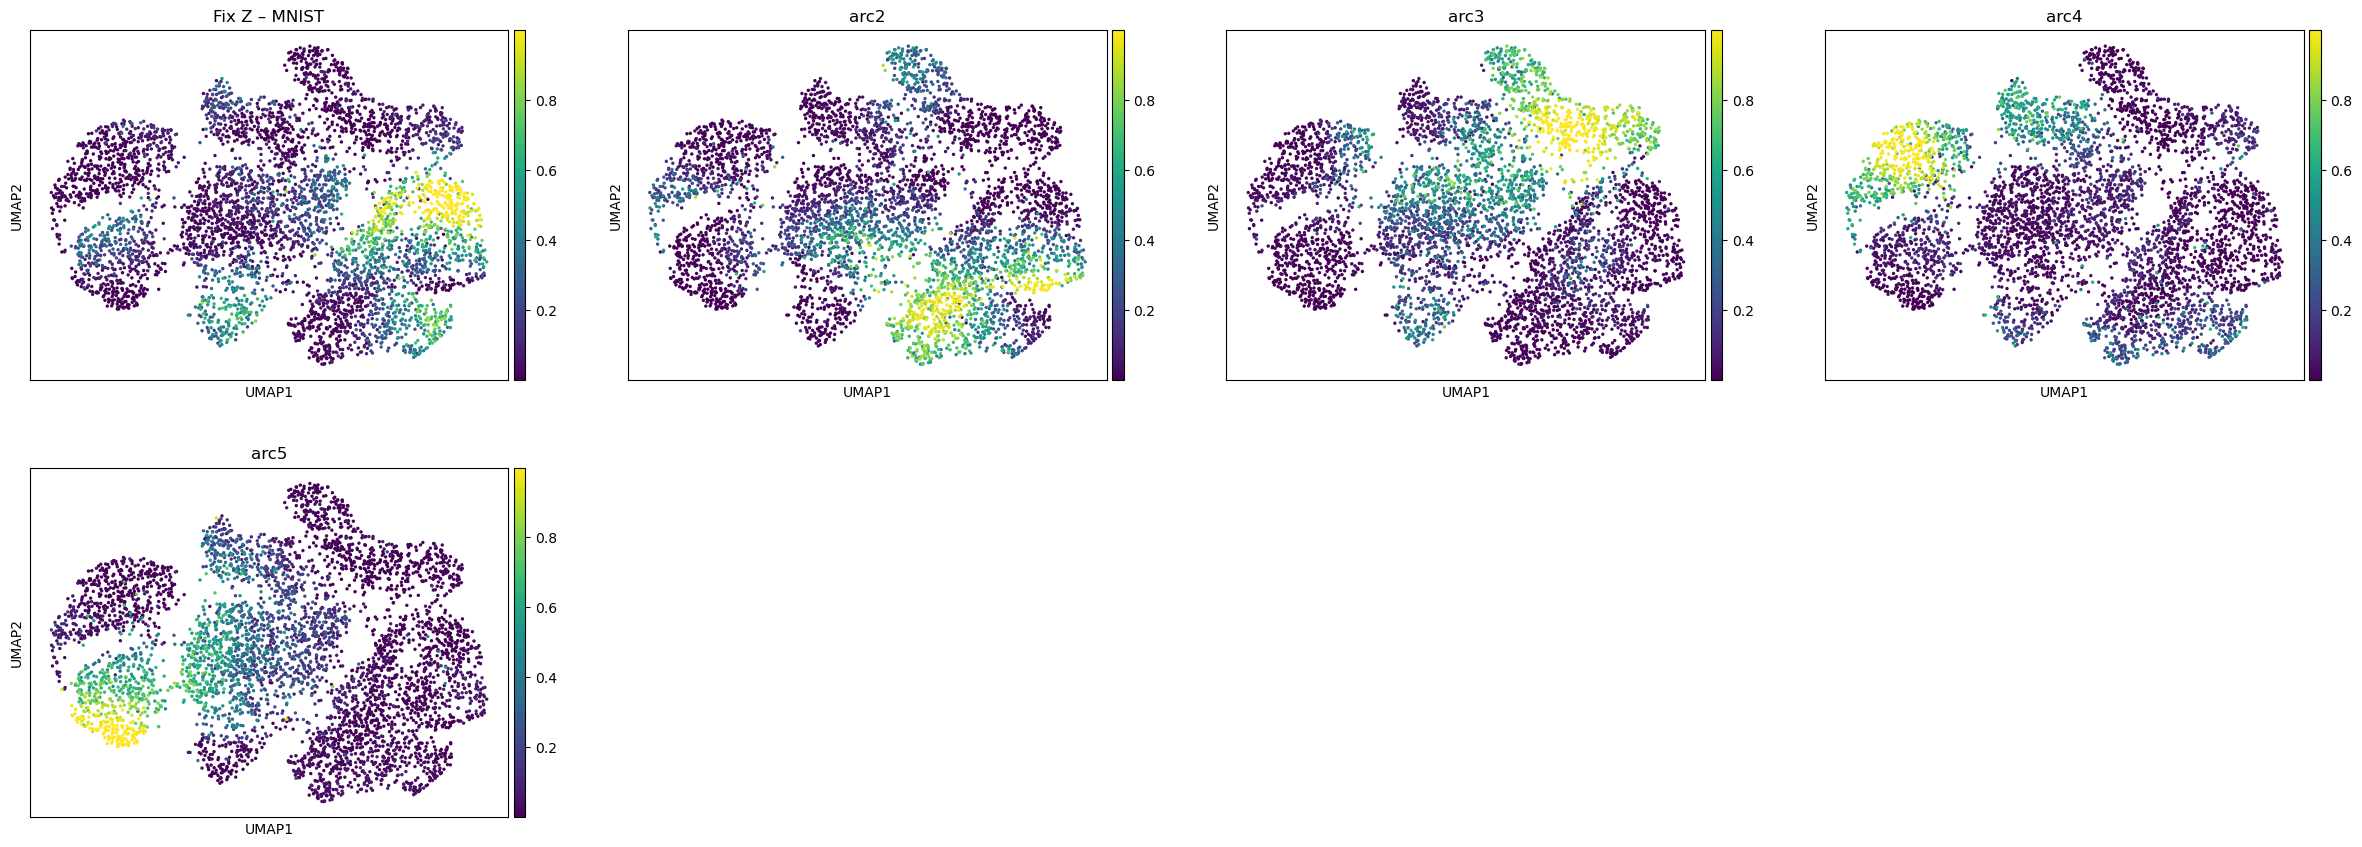

In [15]:
# fix_Z
res_fixZ = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.001,
    steps=500,
    narchetypes=narchetypes,
    fix_Z=True,
    Z_fix_norm=1e8,
    Z_fix_release_step=400
)

adata_fixZ, arc_fixZ = maa.add_to_obs_adata(res_fixZ, adata.copy())
sc.pp.neighbors(adata_fixZ, use_rep="X")
sc.tl.umap(adata_fixZ)
sc.pl.umap(adata_fixZ, color=arc_fixZ, title="Fix Z – MNIST")


ELBO: 21826308.00000  : 100%|█████████████████| 500/500 [01:20<00:00,  6.18it/s]


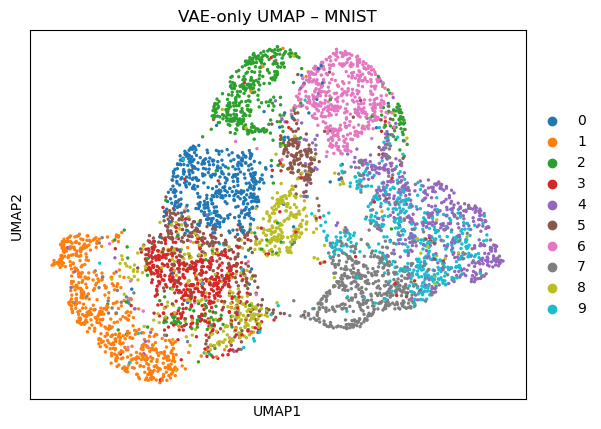

In [16]:
# VAE Only Mode
res_vae = maa.fit_MIDAA(
    input_data,
    normalization,
    likelihoods,
    lr=0.001,
    steps=500,
    just_VAE=True,
    narchetypes=narchetypes
)

adata_vae, arc_vae = maa.add_to_obs_adata(res_vae, adata.copy())
adata_vae.obsm["X_VAE"] = res_vae["inferred_quantities"]["Z"]

sc.pp.neighbors(adata_vae, use_rep="X_VAE")
sc.tl.umap(adata_vae)
sc.pl.umap(adata_vae, color="label", title="VAE-only UMAP – MNIST")


ELBO: 18873510.00000  : 100%|███████████████| 1000/1000 [03:24<00:00,  4.90it/s]


AttributeError: 'Legend' object has no attribute 'legendHandles'

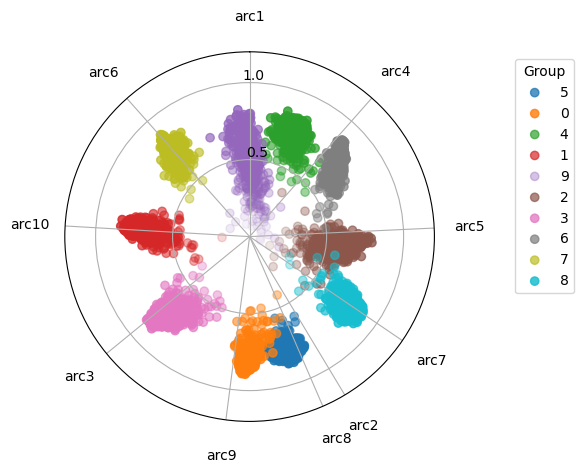

In [17]:
# Supervised MIDAA
side_mat = pd.get_dummies(adata.obs["label"], prefix="digit").to_numpy().astype(float)

res_sup = maa.fit_MIDAA(
    [adata.X],
    [np.ones(adata.n_obs)],
    ["G"],
    side_matrices=[side_mat],
    input_types_side=["C"],
    lr=0.001,
    steps=1000,
    narchetypes=10,
    loss_weights_side=[1],
    loss_weights_reconstruction=[0]
)

maa.plot_archetypes_simplex(
    res_sup,
    color_by=adata.obs["label"],
    cmap="tab10"
)
plt.show()


ELBO: 20837198.00000  : 100%|███████████████| 1000/1000 [01:48<00:00,  9.19it/s]


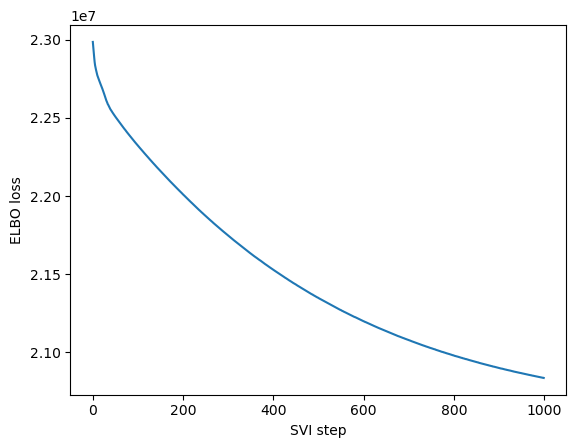

AttributeError: 'Legend' object has no attribute 'legendHandles'

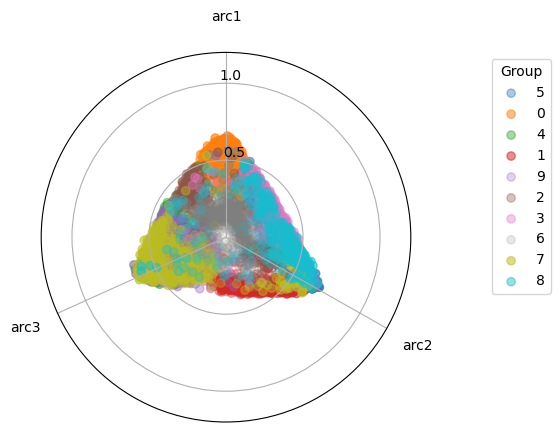

In [19]:
# Encoder/Decoder Test

res_test = maa.fit_MIDAA(
    [adata.X],
    [np.ones(adata.n_obs)],
    ["G"],
    hidden_dims_dec_common=[256,256],
    hidden_dims_dec_last=[512],
    hidden_dims_enc_ind=[512],
    hidden_dims_enc_common=[256,256],
    hidden_dims_enc_pre_Z=[128,64],
    lr=0.001,
    gamma_lr=0.1,
    steps=1000,
    narchetypes=3,
    fix_Z=False
)

maa.plot_ELBO(res_test)
plt.show()

maa.plot_archetypes_simplex(
    res_test,
    color_by=adata.obs["label"],
    cmap="tab10"
)
